# API 2000 tank vent-demand and capacity screening

This example uses NeqSim's edition-aware `Api2000TankVentingScreeningKernel` for the current `API-2000 7th Ed` basis. It aggregates verified caller-controlled normal in-/out-breathing demand and compares normal and total emergency demand with externally rated vent capacity and tank pressure/vacuum limits.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not API compliance or vent sizing. The demand factors/cases, combinations, device curves, reference conditions, and tank limits are caller evidence. API equations/tables, scenario derivation, device selection, line losses, flame arresters, blanketing, floating/refrigerated tanks, testing, and approval remain external.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-q4vnje46 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_api2000


## 1. Verified demonstration basis

All gas demands and capacities below use the stated common reference conditions. The movement ratios, thermal/other demands, total emergency demand, device capacities at rated conditions, scenario combinations, and tank limits would come from the purchased standard, controlled project calculations, tank data, and manufacturer evidence. The flags attest that those records were reviewed; the flags are not the evidence.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.Api2000TankVentingScreeningKernel')
Input = JClass('neqsim.process.engineering.calculation.Api2000TankVentingScreeningKernel$Input')

edition = StandardEdition.defaultEdition(StandardType.API_2000)
kernel = Kernel()

def run_screen(fill_rate=0.10, withdrawal_rate=0.08, capacity_verified=True):
    vent_input = (Input.builder(edition, 'Tank')
        .liquidFillingRateM3PerS(fill_rate)
        .fillingOutbreathingVolumeRatio(1.05)
        .liquidWithdrawalRateM3PerS(withdrawal_rate)
        .withdrawalInbreathingVolumeRatio(1.0)
        .thermalOutbreathingRateM3PerS(0.02)
        .thermalInbreathingRateM3PerS(0.03)
        .otherNormalOutbreathingRateM3PerS(0.005)
        .otherNormalInbreathingRateM3PerS(0.005)
        .totalEmergencyOutbreathingRateM3PerS(0.5)
        .normalOutbreathingRatedCapacityM3PerS(0.2)
        .normalInbreathingRatedCapacityM3PerS(0.15)
        .emergencyOutbreathingRatedCapacityM3PerS(0.6)
        .tankMaximumPositiveGaugePressurePa(5000.0)
        .tankMaximumVacuumPressurePa(2000.0)
        .normalOutbreathingRatedGaugePressurePa(3000.0)
        .normalInbreathingRatedVacuumPressurePa(1500.0)
        .emergencyOutbreathingRatedGaugePressurePa(4500.0)
        .flowReferenceTemperatureK(288.15)
        .flowReferencePressurePaAbsolute(101325.0)
        .fixedRoofNonRefrigeratedApplicabilityVerified(True)
        .ventDemandBasisVerified(True)
        .ratedCapacityBasisVerified(capacity_verified)
        .pressureVacuumBasisVerified(True)
        .normalCombinationBasisVerified(True)
        .emergencyCombinationBasisVerified(True)
        .build())
    return kernel.calculate(vent_input, None)

result = run_screen()
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'normal outbreathing demand [reference m3/s]': float(assessment.getRequiredNormalOutbreathingRateM3PerS()),
    'normal inbreathing demand [reference m3/s]': float(assessment.getRequiredNormalInbreathingRateM3PerS()),
    'total emergency demand [reference m3/s]': float(assessment.getRequiredEmergencyOutbreathingRateM3PerS()),
    'normal outbreathing utilization [-]': float(assessment.getNormalOutbreathingUtilization()),
    'normal inbreathing utilization [-]': float(assessment.getNormalInbreathingUtilization()),
    'emergency utilization [-]': float(assessment.getEmergencyOutbreathingUtilization()),
    'all caller-controlled constraints satisfied': bool(assessment.allConstraintsSatisfied()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
assert str(result.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(assessment.getRequiredNormalOutbreathingRateM3PerS()) - 0.13) < 1e-12
assert abs(float(assessment.getEmergencyOutbreathingUtilization()) - 5.0 / 6.0) < 1e-12
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,API-2000 7th Ed
normal outbreathing demand [reference m3/s],0.13
normal inbreathing demand [reference m3/s],0.115
total emergency demand [reference m3/s],0.5
normal outbreathing utilization [-],0.65
normal inbreathing utilization [-],0.766667
emergency utilization [-],0.833333
all caller-controlled constraints satisfied,True
engineering approval required,True


## 2. Maximum liquid-movement sensitivity

The sweep varies maximum filling and withdrawal independently while holding the caller-controlled demand factors and rated capacities fixed. It demonstrates the implemented aggregation and capacity comparison only; it does not select movement factors, define simultaneous cases, or establish an allowable operating envelope.

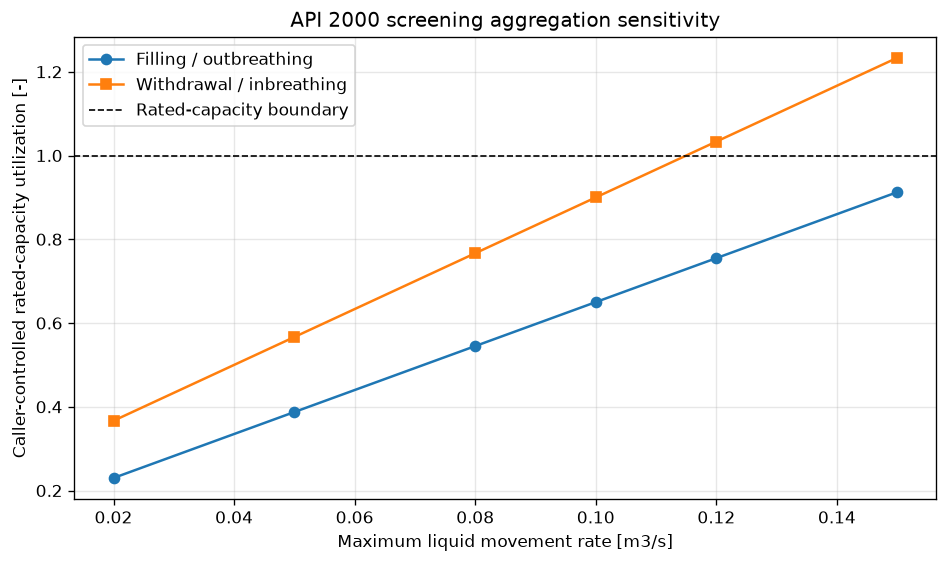

In [3]:
movement_rates = [0.02, 0.05, 0.08, 0.10, 0.12, 0.15]
rows = []
for movement_rate in movement_rates:
    fill_value = run_screen(fill_rate=movement_rate).getValue()
    withdrawal_value = run_screen(withdrawal_rate=movement_rate).getValue()
    rows.append({
        'liquid movement [m3/s]': movement_rate,
        'outbreathing utilization [-]': float(fill_value.getNormalOutbreathingUtilization()),
        'inbreathing utilization [-]': float(withdrawal_value.getNormalInbreathingUtilization()),
    })
sensitivity = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(sensitivity['liquid movement [m3/s]'], sensitivity['outbreathing utilization [-]'], marker='o', label='Filling / outbreathing')
ax.plot(sensitivity['liquid movement [m3/s]'], sensitivity['inbreathing utilization [-]'], marker='s', label='Withdrawal / inbreathing')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, label='Rated-capacity boundary')
ax.set_xlabel('Maximum liquid movement rate [m3/s]')
ax.set_ylabel('Caller-controlled rated-capacity utilization [-]')
ax.set_title('API 2000 screening aggregation sensitivity')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
assert sensitivity['outbreathing utilization [-]'].is_monotonic_increasing
assert sensitivity['inbreathing utilization [-]'].is_monotonic_increasing
plt.show()

**Figure discussion.** With this demonstration basis, utilization increases linearly because the movement contribution is rate multiplied by a fixed caller-controlled volume ratio, while thermal/other demand and rated capacity stay fixed. Outbreathing reaches approximately 0.91 at 0.15 m3/s filling; inbreathing reaches approximately 1.23 at the same withdrawal rate. The engineering implication is that withdrawal becomes the first rated-capacity constraint for this illustrative equipment basis. Recalculate with controlled operating cases and verified vendor curves, then either restrict movement or redesign the vent system if a project case exceeds unity; do not treat the plotted crossing as an API acceptance limit.

## 3. Fail closed when device-rating evidence is missing

A numeric capacity does not establish a defensible device rating. The same values are therefore blocked when the rated-capacity attestation is false. Retain manufacturer curves, gas basis, settings/tolerances, installed-device combination, line losses, and accountable review beside the calculation.

In [4]:
blocked = run_screen(capacity_verified=False)
findings = pd.DataFrame([{
    'code': str(item.toMap().get('code')),
    'severity': 'BLOCKER',
    'message': str(item.toMap().get('message')),
} for item in blocked.getReadiness().getBlockers()])
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
assert 'API_2000_CAPACITY_NOT_VERIFIED' in set(findings['code'])
findings

,code,severity,message
0,API_2000_CAPACITY_NOT_VERIFIED,BLOCKER,Rated vent capacities have not been verified
